# Week 3 - Day 3 - Hands On Lab
Building a Classifier (Logistic Regression)

## Objective

Today I'm training my first classifier — Logistic Regression — to predict whether a patient has diabetes (Pima Indians Diabetes dataset). Before touching any of the 5 official lab steps, I want to actually explore the data myself first — check its shape, its balance, and whether anything looks suspicious — the same way I approached EDA in Week 2, instead of assuming what's wrong with it in advance.

---

## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, roc_auc_score

---

## Load Data

The dataset has no header row, so I assign the column names myself.

In [2]:
cols = ["Pregnancies", "Glucose", "BloodPressure", "SkinThickness", "Insulin",
        "BMI", "DiabetesPedigreeFunction", "Age", "Outcome"]
df = pd.read_csv("data/pima-indians-diabetes.csv", header=None, names=cols)
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


---

## Explore the Data

Before assuming anything is wrong with this data, I check it myself — shape, summary statistics, and target balance.

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [4]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


**What I notice:** looking at the `min` row for `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, and `BMI` — every one of them shows a minimum of `0`. A living person can't have 0 blood pressure or 0 BMI, so these aren't real measurements — they're missing values disguised as zeros. I need to confirm how widespread this is before deciding what to do about it.

In [5]:
for col in ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]:
    zero_count = (df[col] == 0).sum()
    zero_pct = zero_count / len(df) * 100
    print(f"{col}: {zero_count} zeros ({zero_pct:.1f}%)")

Glucose: 5 zeros (0.7%)
BloodPressure: 35 zeros (4.6%)
SkinThickness: 227 zeros (29.6%)
Insulin: 374 zeros (48.7%)
BMI: 11 zeros (1.4%)


**What this tells me:** `Glucose`, `BloodPressure`, and `BMI` have only a handful of zeros (under 5%) — small enough to just drop those rows. `SkinThickness` (29.6%) and `Insulin` (48.7%) are affected far more — dropping that many rows would throw away too much real data, so I'll drop those two columns entirely instead.

Here's what that hidden missingness actually looks like — a histogram of `Insulin` makes the problem obvious:

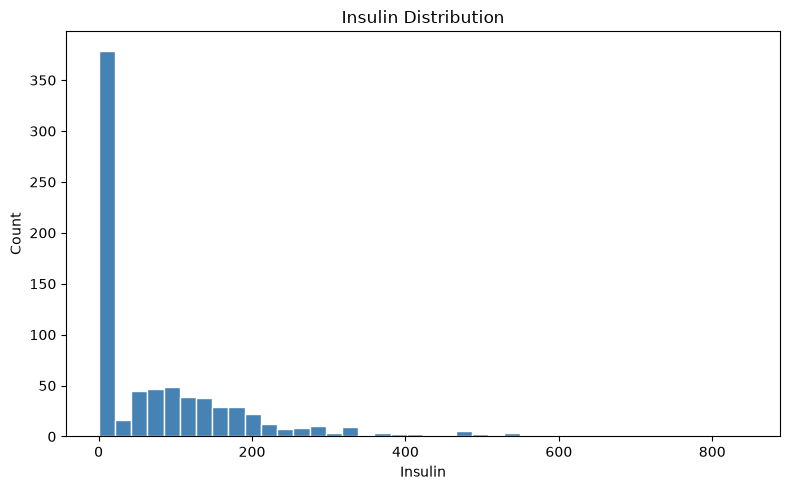

In [6]:
plt.figure(figsize=(8, 5))
plt.hist(df["Insulin"], bins=40, color="steelblue", edgecolor="white")
plt.xlabel("Insulin")
plt.ylabel("Count")
plt.title("Insulin Distribution")
plt.tight_layout()
plt.show()

That spike at 0 isn't a real cluster of patients with zero insulin — it's nearly half the dataset's missing values, stacked at a value that looks real but isn't.

Now checking the target balance:

In [7]:
df["Outcome"].value_counts(normalize=True)

Outcome
0    0.651042
1    0.348958
Name: proportion, dtype: float64

**What this tells me:** about 65% of patients don't have diabetes and 35% do. It's not extreme, but it's imbalanced enough that accuracy alone could be misleading (Section 5 of my learning notebook) — a model that always predicts "no diabetes" would already score close to 65% without learning anything. I'll need the confusion matrix and recall, not just accuracy, to judge this model fairly.

---

## Prepare the Data

Based on what I found above: drop the rows with impossible zeros in `Glucose`, `BloodPressure`, and `BMI`; drop `SkinThickness` and `Insulin` entirely since too much of each is missing.

In [8]:
for col in ["Glucose", "BloodPressure", "BMI"]:
    df = df[df[col] != 0]
df = df.drop(columns=["SkinThickness", "Insulin"])

print("shape after cleaning:", df.shape)

shape after cleaning: (724, 7)


In [9]:
X = df.drop(columns=["Outcome"])
y = df["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(579, 6) (145, 6) (579,) (145,)


---

## Step 1: Train the Model

I train a Logistic Regression model on all 7 remaining features. Internally, it computes the same weighted sum from yesterday, passes it through sigmoid, and finds the weights that minimize Log Loss (not MSE — the reasoning is in my learning notebook, Section 9).

In [10]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

predictions = model.predict(X_test)
probabilities = model.predict_proba(X_test)

predictions[:10]

array([1, 1, 1, 0, 1, 1, 0, 0, 1, 0])

---

## Step 2: Generate Predictions & Confusion Matrix

Before trusting any single metric, I look at the full breakdown of correct and incorrect predictions.

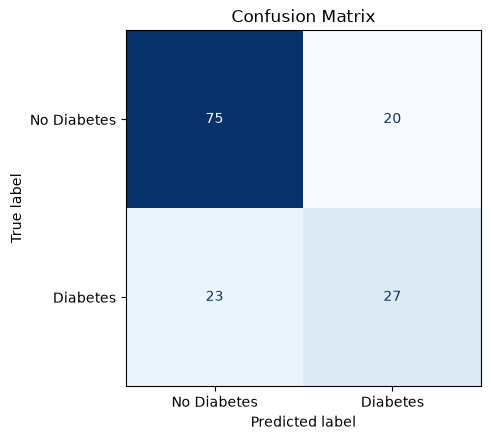

In [11]:
cm = confusion_matrix(y_test, predictions)

from sklearn.metrics import ConfusionMatrixDisplay
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Diabetes", "Diabetes"])
fig, ax = plt.subplots(figsize=(5, 5))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

**Interpretation:** reading the matrix as [[TN, FP], [FN, TP]]: the model correctly identifies most healthy patients, but the False Negatives (diabetic patients predicted as healthy) are the number I care about most here — those are the missed real cases, exactly the risk I flagged when I checked the target balance above.

---

## Step 3: Precision, Recall & F1

Using `classification_report` for a full breakdown per class.

In [12]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.77      0.79      0.78        95
           1       0.57      0.54      0.56        50

    accuracy                           0.70       145
   macro avg       0.67      0.66      0.67       145
weighted avg       0.70      0.70      0.70       145



**Interpretation (class 1 = diabetic):**

- **Precision ≈ 0.57** — when the model predicts "diabetic," it's right about 57% of the time.
- **Recall ≈ 0.54** — of all patients who are actually diabetic, the model only catches about 54% of them.
- **F1 ≈ 0.56** — the balanced score reflects that neither precision nor recall is strong on their own.

Recall being this low is the main concern here — it means the model misses close to half of the real diabetic cases in the test set.

---

## Step 4: Precision or Recall — Which Matters More Here?

For disease screening specifically, **recall matters more than precision**.

- A **false negative** here means telling an actually-diabetic patient they're healthy — a missed diagnosis that delays real treatment.
- A **false positive** means telling a healthy patient they might be diabetic — inconvenient (an extra follow-up test), but not dangerous.

Since the cost of missing a real case is much higher than the cost of a false alarm, I'd rather the model err on the side of flagging more people, even if that lowers precision. At the current default threshold (0.5), recall (0.54) is the weaker of the two — that's the number I'd prioritize improving, for example by lowering the decision threshold so more borderline cases get flagged as positive.

---

## Step 5: AUC-ROC

Precision, recall, and F1 are all tied to one specific threshold (0.5). AUC-ROC evaluates the model across every possible threshold at once.

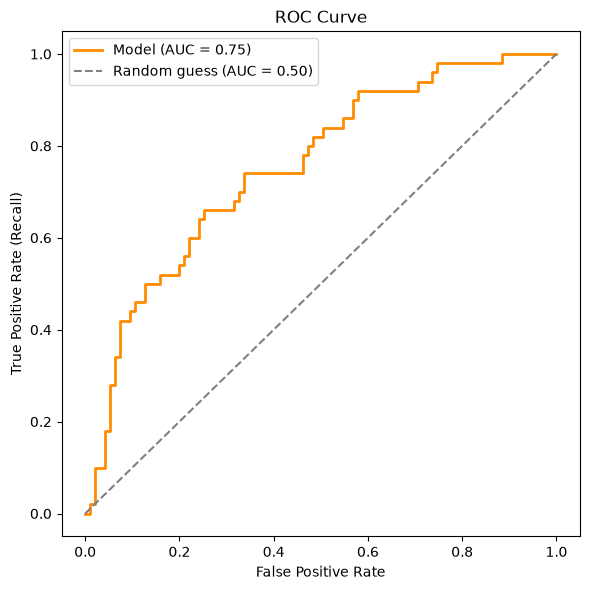

AUC: 0.755


In [13]:
fpr, tpr, thresholds = roc_curve(y_test, probabilities[:, 1])
auc = roc_auc_score(y_test, probabilities[:, 1])

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color="darkorange", linewidth=2, label=f"Model (AUC = {auc:.2f})")
plt.plot([0, 1], [0, 1], color="gray", linestyle="--", label="Random guess (AUC = 0.50)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve")
plt.legend()
plt.tight_layout()
plt.show()

print(f"AUC: {auc:.3f}")

**Interpretation:** AUC ≈ 0.75 — meaningfully better than random guessing (0.50), meaning the model has real predictive signal across all thresholds, not just the default one. This is useful context: even though recall at the default 0.5 threshold is weak (Step 3), the AUC shows the model *does* rank diabetic patients as higher-risk in general — lowering the threshold (Step 4's suggestion) should genuinely help recall, rather than just adding noise.

---

## Summary

I started by exploring the data myself instead of assuming what was wrong with it — that's how I found the hidden missing values (zeros in physiologically impossible places) and confirmed the class imbalance (~35% diabetic) before touching any modeling. After cleaning based on those findings, I trained a Logistic Regression model that reached an AUC of about 0.75, showing real predictive signal, but its recall at the default threshold (0.54) means it currently misses close to half of actual diabetic cases. For a disease-screening problem, I decided recall matters more than precision, since missing a real case is more costly than a false alarm — accuracy alone (which would have looked reasonable at ~70%) would have hidden this weakness completely.